# DTEx231A. LodeSTAR to Detect Particles

<a href="https://colab.research.google.com/github/DeepTrackAI/DeepTrack2/blob/develop/tutorials/2-examples/DTEx231A_LodeSTAR_autotracker_template.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
# !pip install deeplay deeptrack  # Uncomment if running on Colab/Kaggle.

This example shows how to set up and train a LodeSTAR model to detect quantum dots.

In [18]:
import deeptrack as dt
import deeplay as dl
import matplotlib.pyplot as plt
import numpy as np
import torch

## 1. Loading the Images of Quantum Dots

The data is found in the `tutorials/2-examples/assets` directory as an array with the format (time, height, width).

In [19]:
images = np.load("./assets/image_quantum_dots.npy")

Normalize the array.

In [20]:
images = (images - np.min(images)) / np.ptp(images)

Plot a sample of the array.

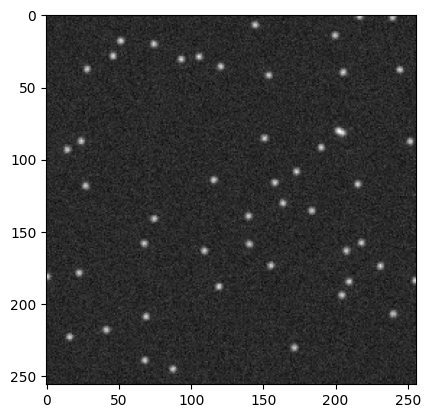

In [21]:
plt.imshow(images[0], cmap="gray")
plt.show()

## 2. Cropping One Quantum Dot

Select a crop of the training data.

In [ ]:
crop = images[0, 100:132, 100:132]

Plot the crop.

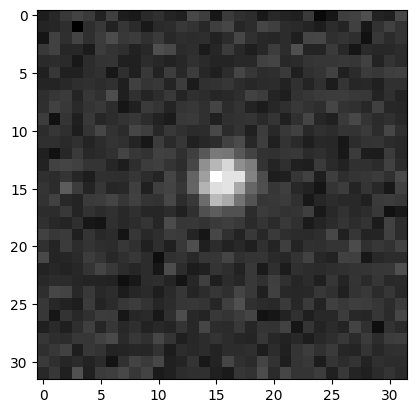

In [23]:
plt.imshow(crop, cmap="gray")

## 4. Training LodeSTAR
Initialize the training dataset and dataloader.

In [31]:
training_data = dt.Value(crop)

dataset = dt.pytorch.Dataset(
    training_data,
    length=128,
)

dataloader = dl.DataLoader(
    dataset=dataset,
    batch_size=4,
)

Initialize the LodeSTAR application containing both a CNN model and training logic.

In [25]:
lodestar = dl.LodeSTAR(
    n_transforms=4,
    optimizer=dl.Adam(lr=1e-3),
).build()

Initialize the trainer.

In [26]:
lodestar_trainer = dl.Trainer(accelerator="auto", max_epochs=50)

Train the model.

In [27]:
lodestar_trainer.fit(lodestar, dataloader)

┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type                       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model         │ ConvolutionalNeuralNetwork │  251 K │ train │     0 │
│ 1 │ between_loss  │ L1Loss                     │      0 │ train │     0 │
│ 2 │ within_loss   │ L1Loss                     │      0 │ train │     0 │
│ 3 │ train_metrics │ MetricCollection           │      0 │ train │     0 │
│ 4 │ val_metrics   │ MetricCollection           │      0 │ train │     0 │
│ 5 │ test_metrics  │ MetricCollection           │      0 │ train │     0 │
│ 6 │ optimizer     │ Adam                       │      0 │ train │     0 │
└───┴───────────────┴────────────────────────────┴────────┴───────┴───────┘

Trainable params: 251 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 251 K                                                                                                
Total estimated model params size (MB): 1                                                                          
Modules in train mode: 39                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Training: |          | 0/? [00:00<?, ?it/s]

## 5. Testing the Trained Model

Convert the images to Pytorch tensors for compatability. 

In [28]:
images_tensor = torch.from_numpy(images).to(torch.float32).moveaxis(-1, 1)

Choose inference parameters for particle detection and run detection.

In [32]:
alpha = 0.5
beta = 1 - alpha
cutoff = 0.9

all_detections = lodestar.detect(
    images_tensor, alpha=alpha, beta=beta, cutoff=cutoff, mode="quantile"
)

Overlay LodeSTAR predictions with the data to validate the model.

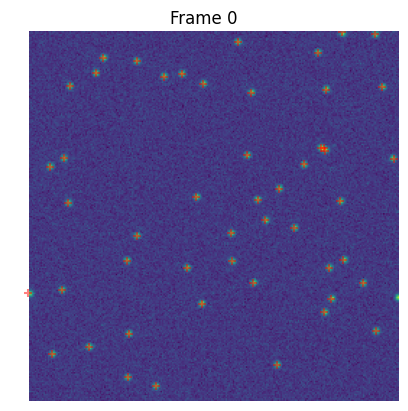

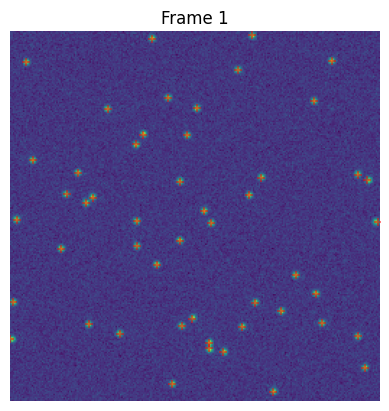

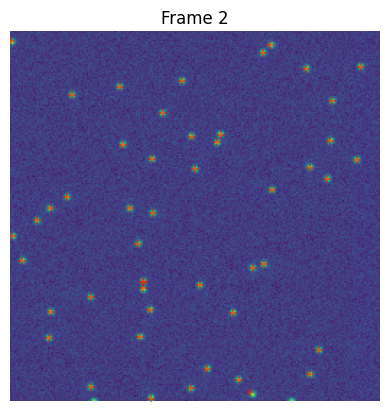

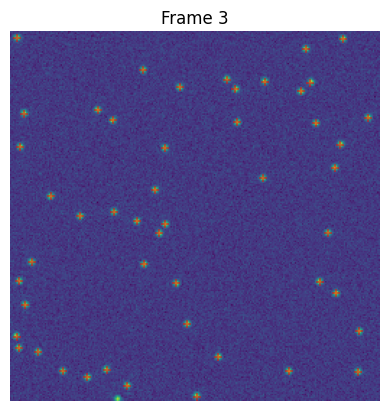

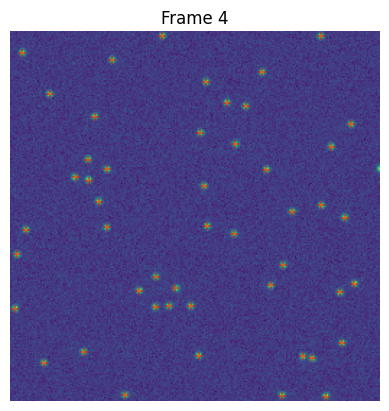

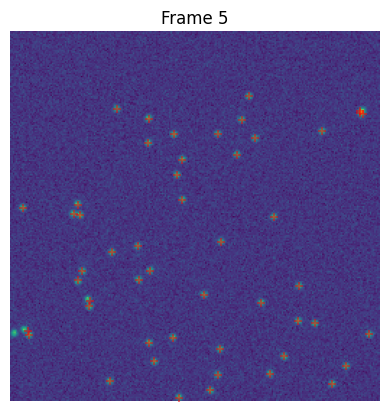

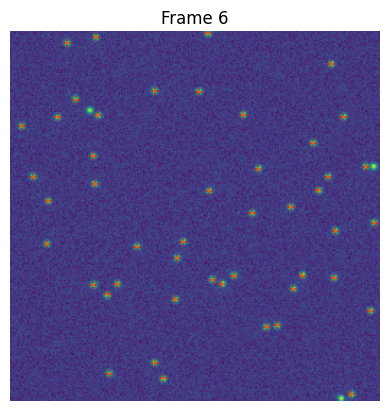

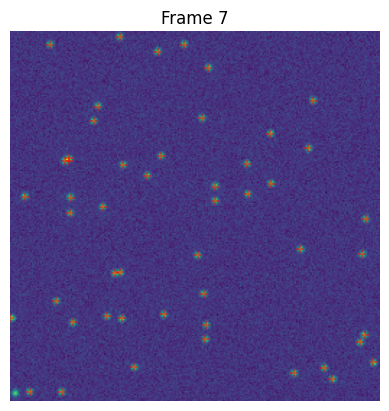

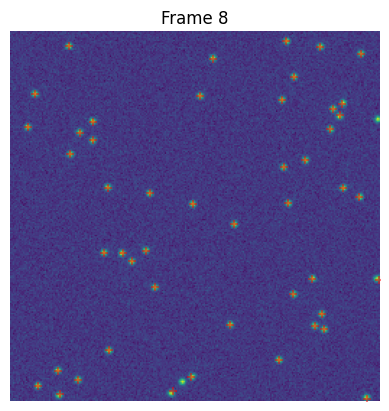

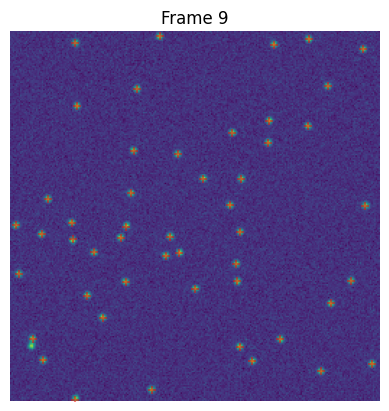

In [30]:
for i, (frame, detections) in enumerate(zip(images_tensor, all_detections)):
    plt.imshow(frame.squeeze(0).detach().cpu())
    plt.scatter(
        detections[:, 1], detections[:, 0], marker="+", c="r", alpha=0.5
    )
    plt.axis("off")
    plt.title(f"Frame {i}")
    plt.show()